In [3]:
import Pkg
Pkg.add("Kinbiont");
Pkg.add("CSV");
Pkg.add("DataFrames");
Pkg.add("Plots");
Pkg.add("Statistics");
Pkg.add("DecisionTree");
Pkg.add("AbstractTrees");
Pkg.add("MLJDecisionTreeInterface");
Pkg.add("TreeRecipe");
Pkg.add("Random");
Pkg.add("DelimitedFiles");

using Kinbiont, CSV, DataFrames, Plots, Statistics, DecisionTree, AbstractTrees
using MLJDecisionTreeInterface, TreeRecipe, Random,DelimitedFiles

   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Manifest.toml`
   Resolving package versions...
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks\Project.toml`
  No Changes to `E:\Lavoro\Kinbiont_utilities_final\Kinbiont_utilities-main\Notebooks\Notebooks

In this example we consider the result of the fit with Richards model of N.soli. The data are from  ["High-throughput characterization of bacterial responses to complex mixtures of chemical pollutants"](https://www.nature.com/articles/s41564-024-01626-9).


We start importing the fit results and the feature matrix and cleaning them up for Kinbiont:

In [5]:
Kinbiont_res_test = readdlm("../DT_antibiotics_interactions/df_for_ML/res_clean_ML_richards.csv", ',');
annotation_test = readdlm("../DT_antibiotics_interactions/df_for_ML/annotation_clean_richards.csv", ',');

We read in the annotation the order of the strains and we set the feature names

In [21]:
ordered_strain = annotation_test[:, end];
feature_names = unique(annotation_test[1, 2:end])[2:(end-1)];

We select the parts of the annotation and results matrix that contains the N.soli. We obtain a a feature matrix in which for each well is annotated if a chemical is present (1) or not (0), and the first row is an unique identifier for each sample.

In [22]:
index_strain = findall("N. soli" .== ordered_strain);
feature_matrix = annotation_test[index_strain, 2:(end-1)]

1199×9 Matrix{Any}:
 "10501_E2_N. soli_"   0  0  0  1  0  0  0  0
 "10502_C11_N. soli_"  1  1  0  1  0  1  1  0
 "10503_E4_N. soli_"   1  0  0  1  0  1  1  1
 "10504_F4_N. soli_"   0  1  0  1  0  0  0  0
 "10505_G2_N. soli_"   1  0  1  1  0  1  1  0
 "10506_F3_N. soli_"   1  0  0  1  0  0  0  0
 "10507_C8_N. soli_"   0  0  0  1  1  1  1  0
 "10508_D7_N. soli_"   0  0  0  0  1  0  0  1
 "10509_F10_N. soli_"  1  0  1  0  1  0  1  0
 "10510_F3_N. soli_"   1  1  1  0  1  1  1  1
 ⋮                                 ⋮        
 "11692_C4_N. soli_"   1  0  0  1  1  1  0  1
 "11693_G7_N. soli_"   0  0  0  0  0  0  1  1
 "11694_F11_N. soli_"  1  0  0  1  1  0  1  0
 "11695_F6_N. soli_"   0  0  0  0  0  0  0  0
 "11696_C3_N. soli_"   0  0  0  0  0  0  0  1
 "11697_D7_N. soli_"   0  0  1  1  0  0  1  1
 "11698_F4_N. soli_"   0  1  1  0  0  0  1  1
 "11699_B11_N. soli_"  1  0  1  0  0  1  1  0
 "11700_F2_N. soli_"   0  0  0  0  1  0  0  0

The results matrix as that unique identifier as second row

In [16]:
Kinbiont_results = hcat(Kinbiont_res_test[:, 1],Kinbiont_res_test[:, index_strain])

11×1200 Matrix{Any}:
 ""           10501                     …  11700
 "well"            "10501_E2_N. soli_"          "11700_F2_N. soli_"
 "label_exp"       "N. soli"                    "N. soli"
 "model"           "NL_Richards"                "NL_Richards"
 "param_1"        0.790667                     0.650559
 "param_2"        0.000368863           …      1.75864
 "param_3"        0.105459                     0.126044
 "param_4"       24.617                       31.7395
 "th_gr"          0.498186                     0.0704354
 "em_gr"          0.59247                      0.0918399
 "loss"           0.00636465            …      0.000280771

We set some parameter of the decion tree and we perdom the regression on growth rate for example (row 9 of the results). In this case we do not set the maxdepth to see the importance scores

In [17]:
seed = Random.seed!(1234)
n_folds = 10
dt_gr = downstream_decision_tree_regression(Kinbiont_results,
            feature_matrix,
            9;
            do_pruning=false,
            pruning_accuracy=1.00,
            verbose=true,
            do_cross_validation=true,
            max_depth=-1,
            n_folds_cv=n_folds,
            seed=seed
)


Fold 1
Mean Squared Error:     0.003046223012946249
Correlation Coeff:      0.9206661987584561
Coeff of Determination: 0.8373893524295764

Fold 2
Mean Squared Error:     0.003144492254958002
Correlation Coeff:      0.9215932316257531
Coeff of Determination: 0.8455461661409156

Fold 3
Mean Squared Error:     0.0026062021494846297
Correlation Coeff:      0.9172773082408823
Coeff of Determination: 0.8387997842897681

Fold 4
Mean Squared Error:     0.0025997640834785176
Correlation Coeff:      0.9437214649310057
Coeff of Determination: 0.8900034388423166

Fold 5
Mean Squared Error:     0.003967049065450292
Correlation Coeff:      0.8988547591874487
Coeff of Determination: 0.803446565864572

Fold 6
Mean Squared Error:     0.0033530691758609627
Correlation Coeff:      0.9347488406221022
Coeff of Determination: 0.8695862178809449

Fold 7
Mean Squared Error:     0.0035484184784741143
Correlation Coeff:      0.9187405598687651
Coeff of Determination: 0.8423201773800824

Fold 8
Mean Squared Err

(Decision Tree
Leaves: 128
Depth:  7, [5.349628330447265e-5, 7.052945996698044e-5, 0.0003233338435700716, 5.454634964415838e-5, 0.009885198984231769, 0.000151753305228941, 5.7036959129554276e-5, 0.008934942575959353], [15.0, 17.0, 26.0, 28.0, 11.0, 22.0, 7.0, 1.0], [0.8373893524295764, 0.8455461661409156, 0.8387997842897681, 0.8900034388423166, 0.803446565864572, 0.8695862178809449, 0.8423201773800824, 0.8539849121853045, 0.8565982166646746, 0.9017757977489602], Any["values" 1.0 … 128.0 128.0; "cluster" 0.468353225973557 … 0.08752099334097899 0.03568178527096875])

In [25]:
println("Cross validation results (R^2)")
dt_gr[4]


Cross validation results


10-element Vector{Float64}:
 0.8373893524295764
 0.8455461661409156
 0.8387997842897681
 0.8900034388423166
 0.803446565864572
 0.8695862178809449
 0.8423201773800824
 0.8539849121853045
 0.8565982166646746
 0.9017757977489602

In [26]:
println(string("the feature order is, ", feature_names))

the feature order is, Any["Amoxicillin", "Chlorothalonil", "Diflufenican", "Glyphosate", "Imidacloprid", "Metaldehyde", "Oxytetracycline", "Tebuconazole"]


In [27]:
println("Importance scores")
dt_gr[2]


Importance scores


8-element Vector{Float64}:
 5.349628330447265e-5
 7.052945996698044e-5
 0.0003233338435700716
 5.454634964415838e-5
 0.009885198984231769
 0.000151753305228941
 5.7036959129554276e-5
 0.008934942575959353

In [28]:
println("Importance ranks")
dt_gr[3]


Importance ranks


8-element Vector{Float64}:
 15.0
 17.0
 26.0
 28.0
 11.0
 22.0
  7.0
  1.0

In [29]:
println("the association of a sample value to a leaf (i.e., cluster)")
dt_gr[5]


the association of a sample value to a leaf (i.e., cluster)


2×1200 Matrix{Any}:
 "values"   1.0       1.0       …  128.0       128.0       128.0
 "cluster"  0.468353  0.443926       0.069422    0.087521    0.0356818

We perform again the tree with depth 2 to visualize it better:

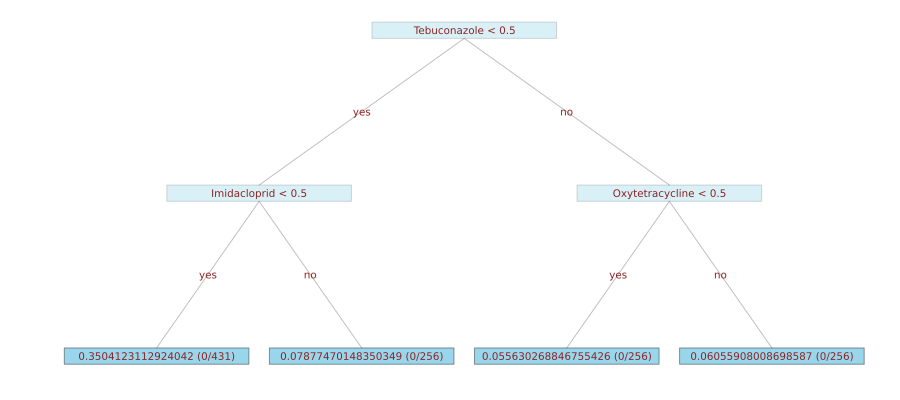


Fold 1
Mean Squared Error:     0.0035183317400329073
Correlation Coeff:      0.9266640140284664
Coeff of Determination: 0.8529208207663308

Fold 2
Mean Squared Error:     0.003837256586961132
Correlation Coeff:      0.9150408595078561
Coeff of Determination: 0.837026651850548

Fold 3
Mean Squared Error:     0.0023674245378576693
Correlation Coeff:      0.9470424691574795
Coeff of Determination: 0.8923261977806132

Fold 4
Mean Squared Error:     0.002576435022868187
Correlation Coeff:      0.9352514298536246
Coeff of Determination: 0.8733406341989066

Fold 5
Mean Squared Error:     0.0025808223809441412
Correlation Coeff:      0.9386093305950557
Coeff of Determination: 0.8804534944447376

Fold 6
Mean Squared Error:     0.003177857861100636
Correlation Coeff:      0.9225890758026511
Coeff of Determination: 0.8253557450392862

Fold 7
Mean Squared Error:     0.0031047875122405316
Correlation Coeff:      0.9347094411171
Coeff of Determination: 0.8698817471578659

Fold 8
Mean Squared Error:

In [31]:
dt_gr = downstream_decision_tree_regression(Kinbiont_results,
            feature_matrix,
            9;
            do_pruning=false,
            pruning_accuracy=1.00,
            verbose=true,
            do_cross_validation=true,
            max_depth=2,
            n_folds_cv=n_folds,
            seed=seed
)


wt = DecisionTree.wrap(dt_gr[1], (featurenames = feature_names,));
 
 
p2 = Plots.plot(wt, 0.9, 0.2; size = (900,400), connect_labels = ["yes", "no"]);
display(p2)